## Business Understanding

Bike sharing systems are new generation of traditional bike rentals where whole process from membership, rental and return back has become automatic. Through these systems, user is able to easily rent a bike from a particular position and return back at another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of over 500 thousands bicycles. Today, there exists great interest in these systems due to their important role in traffic, environmental and health issues. 

Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by these systems make them attractive for the research. Opposed to other transport services such as bus or subway, the duration of travel, departure and arrival position is explicitly recorded in these systems. This feature turns bike sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that most of important events in the city could be detected via monitoring these data.


## Objective
: do a comparison between: 
- Linear Regression 
- Decision Tree Regressor 
- Random Forest 
- Lasso Regression

Considering you have 4 models it would be a good idea to use a function that does the following:
- instantiates the model 
- trains it and returns a tuple containing the prediction and y_test (the essence of this will be to pass it to an evaluation function to check performance)


In [192]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_rainbow
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.regressionplots import plot_ccpr
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings# Ignore all warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.tree import export_graphviz
from scipy import stats  
import graphviz       
pd.set_option('display.max_rows', None)       # show all rows
pd.set_option('display.max_columns', None)    # show all columns
pd.set_option('display.width', None)          # auto-detect display width
pd.set_option('display.max_colwidth', None)   # show full content of each cell

In [158]:
Bike1_df= pd.read_csv("data/day.csv")
Bike2_df= pd.read_csv("data/hour.csv")

In [159]:
bikes_df=pd.concat([Bike1_df,Bike2_df]) ## combine datasets

In [160]:
bikes_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,hr
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,NaN
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,NaN
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,NaN
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,NaN
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,NaN


In [161]:
bikes_df.info()

<class 'pandas.DataFrame'>
Index: 18110 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     18110 non-null  int64  
 1   dteday      18110 non-null  str    
 2   season      18110 non-null  int64  
 3   yr          18110 non-null  int64  
 4   mnth        18110 non-null  int64  
 5   holiday     18110 non-null  int64  
 6   weekday     18110 non-null  int64  
 7   workingday  18110 non-null  int64  
 8   weathersit  18110 non-null  int64  
 9   temp        18110 non-null  float64
 10  atemp       18110 non-null  float64
 11  hum         18110 non-null  float64
 12  windspeed   18110 non-null  float64
 13  casual      18110 non-null  int64  
 14  registered  18110 non-null  int64  
 15  cnt         18110 non-null  int64  
 16  hr          17379 non-null  float64
dtypes: float64(5), int64(11), str(1)
memory usage: 2.7 MB


In [162]:
bikes_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,hr
count,18110.000000,18110.000000,18110.000000,18110.000000,18110.000000,18110.000000,18110.000000,18110.000000,18110.000000,18110.000000,18110.000000,18110.000000,18110.000000,18110.000000,18110.000000,17379.000000
mean,8354.006405,2.501436,0.502485,6.537051,0.028769,3.003424,0.682772,1.424075,0.496922,0.475718,0.627256,0.190113,68.472336,295.158697,363.631033,11.546752
std,5180.771860,1.107045,0.500008,3.439213,0.167160,2.005677,0.465410,0.635830,0.192177,0.171496,0.191147,0.120851,216.588054,771.555142,950.827954,6.914405
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,3797.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,37.000000,43.000000,6.000000
50%,8324.500000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.188951,18.000000,123.000000,152.000000,12.000000
75%,12851.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,55.000000,238.000000,305.000000,18.000000
max,17379.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,3410.000000,6946.000000,8714.000000,23.000000


In [163]:
bikes_df.isnull().sum()

instant         0
dteday          0
season          0
yr              0
mnth            0
holiday         0
weekday         0
workingday      0
weathersit      0
temp            0
atemp           0
hum             0
windspeed       0
casual          0
registered      0
cnt             0
hr            731
dtype: int64

In [164]:
bikes_df.dtypes

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
hr            float64
dtype: object

In [165]:
print(bikes_df.isnull().sum())

instant         0
dteday          0
season          0
yr              0
mnth            0
holiday         0
weekday         0
workingday      0
weathersit      0
temp            0
atemp           0
hum             0
windspeed       0
casual          0
registered      0
cnt             0
hr            731
dtype: int64


In [166]:
np.isnan(X_train_scaled).sum()

np.int64(0)

In [167]:
np.where(np.isnan(X_train_scaled))

(array([], dtype=int64), array([], dtype=int64))

In [168]:
X.columns[11]

'hr'

In [169]:
bikes_df[X.columns[11]].isnull().sum()

np.int64(731)

In [170]:
X = bikes_df.drop('cnt', axis=1)
y = bikes_df['cnt']

In [171]:
df = bikes_df.dropna(subset=['hr', 'cnt'])

In [172]:
bikes_df = bikes_df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)

In [173]:
bikes_df = bikes_df.dropna()

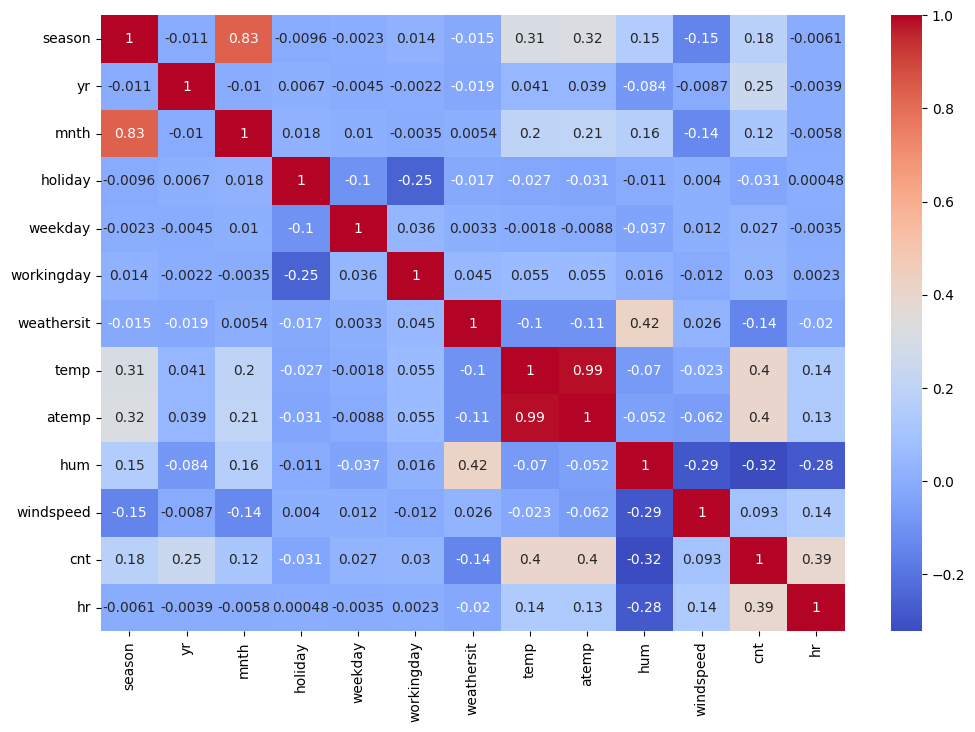

In [174]:
plt.figure(figsize=(12,8))
sns.heatmap(bikes_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [175]:
X = bikes_df.drop('cnt', axis=1) ##Features and Target
y = bikes_df['cnt']

In [176]:
## taintest split
def train_test_model(model, X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    return predictions, y_test

In [177]:
scaler = StandardScaler() ## feature scaling

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [178]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [179]:
##Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [180]:
##Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [181]:
## lasso regression
lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

In [182]:
## evaluate models
def evaluate_model(y_test, predictions):

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    return mae, rmse, r2

In [183]:
## Cross Validation Function
k=5

def cross_validation_model(model, X, y):

    kfold = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    predictions = cross_val_predict(
        model,
        X,
        y,
        cv=kfold
    )

    return predictions, y

In [184]:
## compare results
print("TRAIN TEST SPLIT RESULTS")
print("="*50)
models = {
    'Linear Regression': lr_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred,
    'Lasso Regression': lasso_pred
}

for name, pred in models.items():

    mae, rmse, r2 = evaluate_model(y_test, pred)

    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("-"*40)

TRAIN TEST SPLIT RESULTS
Linear Regression
MAE: 104.80335089554427
RMSE: 139.2114519989348
R2 Score: 0.3879811583139132
----------------------------------------
Decision Tree
MAE: 34.245109321058685
RMSE: 58.30811280098137
R2 Score: 0.8926325010502011
----------------------------------------
Random Forest
MAE: 24.905480653049484
RMSE: 42.08462694856371
R2 Score: 0.9440678093020485
----------------------------------------
Lasso Regression
MAE: 104.77452071759964
RMSE: 139.21008874175953
R2 Score: 0.3879931448995011
----------------------------------------


| Model             | MAE    | RMSE   | R²    |
| ----------------- | ------ | ------ | ----- |
| Linear Regression | 104.80 | 139.21 | 0.388 |
| Decision Tree     | 34.25  | 58.31  | 0.893 |
| Random Forest     | 24.91  | 42.08  | 0.944 |
| Lasso Regression  | 104.77 | 139.21 | 0.388 |


In [185]:
split_df = pd.DataFrame(
    split_results,
    index=['MAE', 'RMSE', 'R2']
).T

print(split_df)

Empty DataFrame
Columns: [MAE, RMSE, R2]
Index: []


insights:
- Random Forest Regressor is the best model because Lowest MAE,Lowest RMSE,Highest R²
- An R² of:
R^2=0.944 means the model explains about 94.4% of the variance in bike rentals.

- Decision Tree achieved:R^2=0.893
- This suggests the dataset has:nonlinear relationships interactions between weather and season variables

- Linear Regression got R^2 of 0.388 insunating the relationship between features and rentals is not purely linear weather effects and seasonal behavior are complex
- Linear Regression struggles with:
feature interactions

Lasso Regression Performed Almost the same suggesting that feature regularization did not improve performance much most features are still useful
the main issue is nonlinearity, not overfitting.

in conculsion Random Forest Regressor achieved the best predictive performance with an R² score of 0.944, indicating that bike rental demand is influenced by nonlinear relationships between weather, seasonal, and temporal variables.

In [186]:
## Feature Importance Plot
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

       Feature  Importance
11          hr    0.612143
7         temp    0.118977
1           yr    0.080795
5   workingday    0.057766
9          hum    0.026793
8        atemp    0.021812
0       season    0.021727
6   weathersit    0.018222
2         mnth    0.016536
4      weekday    0.012413
10   windspeed    0.010275
3      holiday    0.002541


In [187]:
dt_small = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

dt_small.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

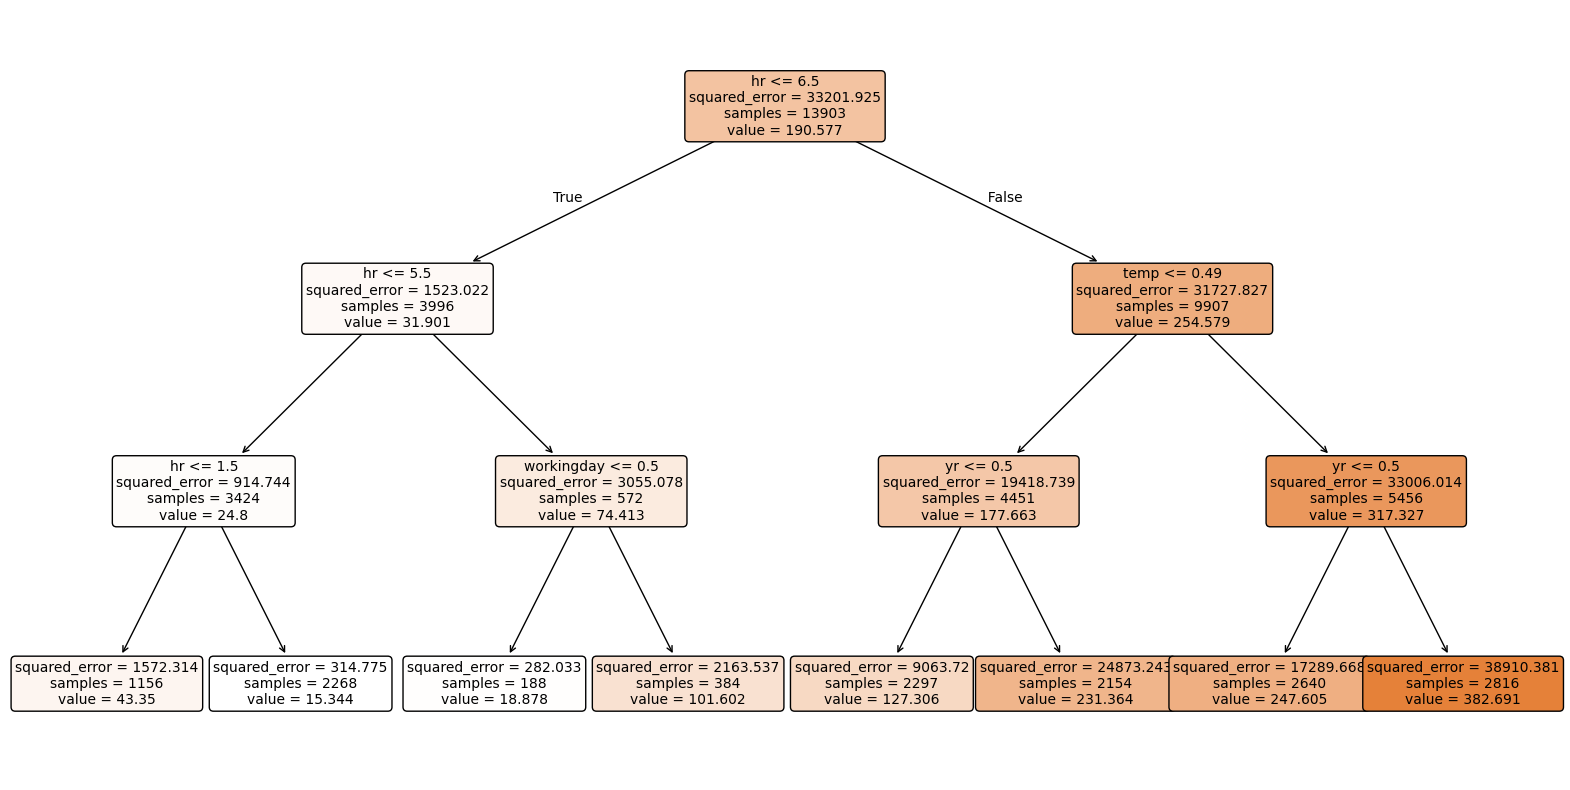

In [188]:
plt.figure(figsize=(20,10))

tree.plot_tree(
    dt_small,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

Feature Importance Visualization

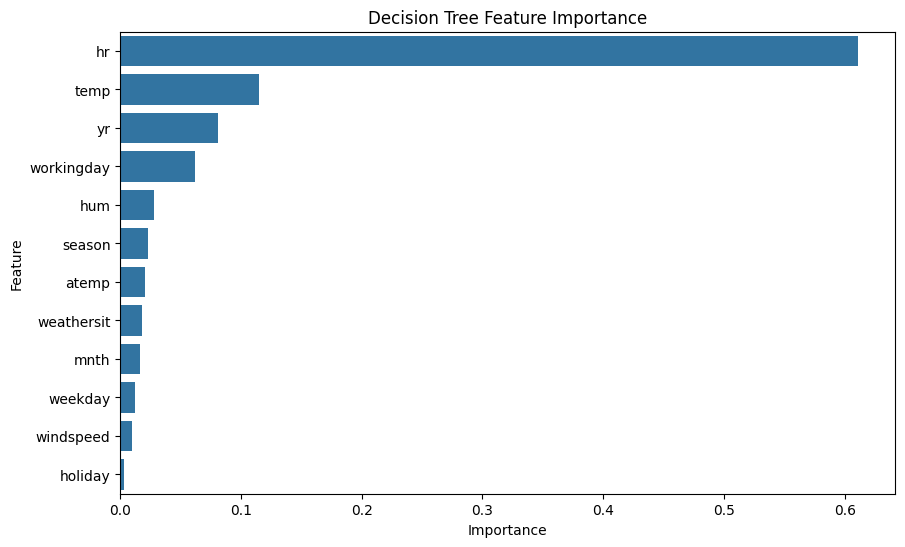

In [191]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Decision Tree Feature Importance")

plt.show()